<a href="https://colab.research.google.com/github/kjmobile/lb2/blob/main/0_colab_intro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Colab Intro: From SQL to a Simple Regression

In this notebook you will:

1. **Run Python in Colab.** Click a cell and press **Shift + Enter**.
2. **Use SQL inside Python** to get data from the class database, the SQL you already learned.
3. **Fit a simple regression** on that data: does a late departure mean a late arrival?

# 0. Connect Database to get the dataset

In [ ]:
! pip install pymysql

In [2]:
# import data from mySQL database  using the following info host: database-klee.cbgcswckszgl.us-east-1.rds.amazonaws.com, id erau, password 1212, db='data', port 3306
import pymysql
import pandas as pd

In [3]:
# 1.1 Practice DB connection
connection = pymysql.connect(
    host='database-klee.cbgcswckszgl.us-east-1.rds.amazonaws.com',
    user='erau',
    password='1212',
    charset='utf8mb4',
    cursorclass=pymysql.cursors.DictCursor
)

cursor = connection.cursor()
print("Connected to database!")

Connected to database!


In [4]:
#1.2 show available databases
cursor.execute("SHOW DATABASES")
print("Available databases:")
for db in cursor.fetchall():
    print(f"- {db['Database']}")

Available databases:
- airline_db
- condo
- hr
- information_schema
- performance_schema
- toy


In [5]:
#1.3 select airline_db by USE commend
cursor.execute("USE airline_db")
print('connected to airline_db')

connected to airline_db


In [6]:
#1.3 airline_db
cursor.execute("SHOW TABLES")
print("\nAvailable tables in airline_db:")
tables = cursor.fetchall()
for table in tables:
    table_name = list(table.values())[0]
    print(f"- {table_name}")


Available tables in airline_db:
- aircraft
- airlines
- airports
- bookings
- flights
- flights_delay
- passengers
- seat_map
- tickets


In [7]:
#1.4 select * from airports table.
cursor.execute("SELECT * FROM airports  WHERE city in ('Paris', 'Tokyo') ")
results =pd.DataFrame(cursor.fetchall())
results

,airport_code,airport_name,city,country,timezone,latitude,longitude
0,CDG,Charles de Gaulle Airport,Paris,France,Europe/Paris,49.00970000,2.54790000
1,HND,Haneda Airport,Tokyo,Japan,Asia/Tokyo,35.54940000,139.77980000
2,NRT,Narita International Airport,Tokyo,Japan,Asia/Tokyo,35.76530000,140.38560000


In [8]:
#1.4 select * from airports table.
cursor.execute("""
SELECT f.flight_number,  a.airline_name
FROM flights f
JOIN airlines a ON f.airline_code = a.airline_code
""")
results =pd.DataFrame(cursor.fetchall())
results

,flight_number,airline_name
0,AA649,American Airlines
1,AA182,American Airlines
2,AA742,American Airlines
3,AA802,American Airlines
4,AA607,American Airlines
...,...,...
210,UA563,United Airlines
211,UA835,United Airlines
212,UA320,United Airlines
213,UA480,United Airlines


In [9]:
cursor.execute('''
SELECT * FROM bookings ORDER BY total_price LIMIT 1
''')
results=pd.DataFrame(cursor.fetchall())
results

,booking_id,passenger_id,booking_date,total_price,currency,payment_status,booking_status
0,BXQTYA,561,2025-07-23 14:52:04,544.81,USD,PAID,CONFIRMED


In [10]:
#1.5 database connection close and cursor close
cursor.close()
connection.close()

---

In [11]:
# 2 Load the flight delay data with a single connection
with pymysql.connect(host='database-klee.cbgcswckszgl.us-east-1.rds.amazonaws.com',
                    user='erau',
                    password='1212',
                    db='airline_db',
                    charset='utf8mb4',
                    cursorclass=pymysql.cursors.DictCursor) as connection:

    with connection.cursor() as cursor:
        # 1. Show available tables in airline_db
        print("Available tables in airline_db:")
        cursor.execute("SHOW TABLES")
        for table in cursor.fetchall():
            print(list(table.values())[0])

        print("\nFetching flights_delay:")
        # 2. Fetch the delays and create a DataFrame
        cursor.execute("""
            SELECT flight_id, departure_delay_mins, delay_minutes AS arrival_delay_mins
            FROM flights_delay
        """)
        df = pd.DataFrame(cursor.fetchall())

# Display the DataFrame
df

Available tables in airline_db:
aircraft
airlines
airports
bookings
flights
flights_delay
passengers
seat_map
tickets

Fetching flights_delay:


,flight_id,departure_delay_mins,arrival_delay_mins
0,1,6,22
1,2,20,62
2,3,12,28
3,4,8,15
4,5,15,27
...,...,...,...
495,496,4,1
496,497,0,0
497,498,9,15
498,499,29,60


---
# A Simple Regression on the Data You Just Loaded

Question: **if a flight leaves late, how late does it arrive?**

`df` now holds 500 flights from `flights_delay`: departure delay and arrival delay, in minutes.

We fit the **same line two ways**, because there are two different purposes:

| | Traditional (statistical) regression | Machine learning |
|---|---|---|
| **Purpose** | **Explain**: is the relationship real, and how big is it? | **Predict**: how well will it work on flights it has never seen? |
| Data | Use **all** the data | **Split** into a training set and a test set |
| Why | More data gives more precise estimates, and the p-value tells us whether the relationship could be chance | A model can look better on the data it learned from than it really is. Only new data shows how well it predicts |

In [12]:
df.head()

,flight_id,departure_delay_mins,arrival_delay_mins
0,1,6,22
1,2,20,62
2,3,12,28
3,4,8,15
4,5,15,27


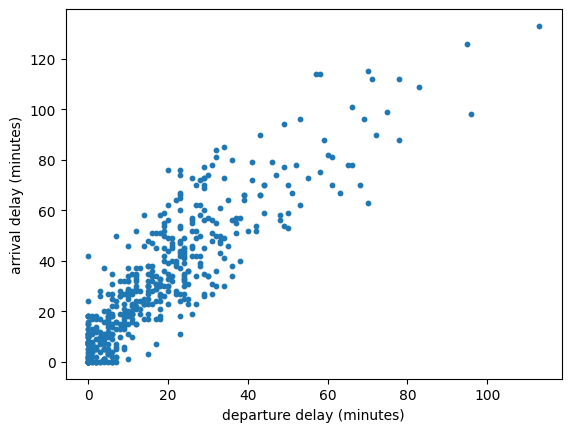

In [13]:
import matplotlib.pyplot as plt

plt.scatter(df['departure_delay_mins'], df['arrival_delay_mins'], s=10)
plt.xlabel('departure delay (minutes)')
plt.ylabel('arrival delay (minutes)')
plt.show()

## 1) Traditional regression: explain the relationship

**Purpose: explain.** We want to know whether departure delay really affects arrival delay, and by how much.
So we use **all 500 flights**: every flight makes the estimate more precise, and the p-value tests whether the
relationship could be chance.

$$\text{arrival delay} = \beta_0 + \beta_1 \times \text{departure delay}$$

In [14]:
import statsmodels.formula.api as smf

model = smf.ols('arrival_delay_mins ~ departure_delay_mins', data=df)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:     arrival_delay_mins   R-squared:                       0.777
Model:                            OLS   Adj. R-squared:                  0.776
Method:                 Least Squares   F-statistic:                     1733.
Date:                Fri, 09 Oct 2026   Prob (F-statistic):          2.66e-164
Time:                        12:48:41   Log-Likelihood:                -1965.3
No. Observations:                 500   AIC:                             3935.
Df Residuals:                     498   BIC:                             3943.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                8.6834 

**How to read it**
- `departure_delay_mins` coefficient: minutes of arrival delay for each extra minute of departure delay.
- `P>|t|` near 0: the relationship is very unlikely to be chance.
- `R-squared`: share of the variation in arrival delays that departure delay explains.

Report it like this: *Departure delay significantly predicted arrival delay, b = 1.29, p < .001, R² = 0.777
(500 flights). Each extra minute of departure delay went with about 1.3 more minutes of arrival delay.*

## 2) Machine learning: predict new flights

**Purpose: predict.** An airline wants to forecast the arrival delay of **tomorrow's** flights, which are not in
the data yet.

**Why split?** A model scored on the same flights it learned from looks better than it really is, like grading a
student on the exact questions they practiced. So we hold back 25% of the flights as a **test set** (a new exam),
fit on the other 75% (the **training set**), and judge the model only on the test set.

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df[['departure_delay_mins']], df['arrival_delay_mins'],
                                                    test_size=0.25, random_state=0)

In [16]:
from sklearn.linear_model import LinearRegression

ml_model = LinearRegression()
ml_model.fit(X_train, y_train)

print('arrival delay =', ml_model.intercept_.round(2), '+', ml_model.coef_[0].round(2), 'x departure delay')

arrival delay = 8.2 + 1.33 x departure delay


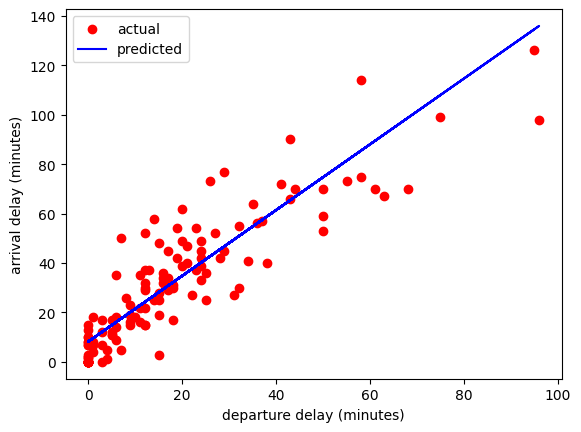

In [17]:
y_pred = ml_model.predict(X_test)

plt.scatter(X_test['departure_delay_mins'], y_test, color='red', label='actual')
plt.plot(X_test['departure_delay_mins'], y_pred, color='blue', label='predicted')
plt.xlabel('departure delay (minutes)')
plt.ylabel('arrival delay (minutes)')
plt.legend()
plt.show()

### Your turn

Fit the machine-learning model yourself: create it, fit it on the **training** set, and score it on the **test** set.

Fill in the blanks:

```python
ml_model = ______________()
ml_model.fit(_______, _______)
print(ml_model.score(______, ______))
```

<details><summary>Show answer</summary>

```python
ml_model = LinearRegression()
ml_model.fit(X_train, y_train)
print(ml_model.score(X_test, y_test))
```
</details>

In [18]:
# Write your code here

## How good are the predictions? R², MSE, RMSE

$$R^2 = 1-\frac{\sum_i (y_i-\hat y_i)^2}{\sum_i (y_i-\bar y)^2}
\qquad
\text{MSE}=\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat y_i)^2
\qquad
\text{RMSE}=\sqrt{\text{MSE}}$$

RMSE is in minutes, like the delays: the typical size of a miss.

In [19]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print('Train R2:', round(ml_model.score(X_train, y_train), 3), ' (flights it learned from)')
print('Test R2: ', round(ml_model.score(X_test, y_test), 3), ' (flights it has never seen)')
print('MSE:     ', round(mse, 1))
print('RMSE:    ', round(mse ** 0.5, 1), 'minutes')

Train R2: 0.775  (flights it learned from)
Test R2:  0.78  (flights it has never seen)
MSE:      153.8
RMSE:     12.4 minutes


**The test R² is the honest score.** It tells you how well the line will predict new flights.

Here train and test R² are close: a straight line with one input has little room to memorize the training flights. With complex models the gap can be large. In notebook 3, a model with 55 features scores 0.82 on its training data but only 0.54 on new data. That is why machine learning always keeps a test set.

## Summary

| | Traditional regression | Machine learning |
|---|---|---|
| Purpose | **Explain** the relationship | **Predict** new cases |
| Data | All of it | Train / test split |
| Tool here | `statsmodels` (`smf.ols`) | `scikit-learn` (`LinearRegression`) |
| Key output | Coefficient, p-value, R² | Test R², RMSE |

The line is the same. What changes is the question you ask, and so how you use the data.

**Next:** the assignment adds the weather to this same model. One more input, one more `+`.